<div style="
    background: linear-gradient(135deg, #e8f4ff, #f4eaff);
    border-left: 7px solid #5271ff;
    padding: 28px;
    border-radius: 14px;
    text-align: center;
">

# ✈️ Time Series Forecasting using ARIMA

## Time Series Forecasting using ARIMA

### 📊 PPredicting Monthly Airline Passenger Traffic

**Prepared by:** Lovisha Jaat 
</div>

## 🎯 Problem Statement

The objective of this notebook is to forecast future airline passenger traffic using the ARIMA (AutoRegressive Integrated Moving Average) model.

Time series forecasting helps businesses and organizations predict future trends based on historical observations.

---

## 📂 Dataset Used

**Dataset:** Airline Passenger Dataset

**Target Variable:** Monthly Number of Airline Passengers

**Frequency:** Monthly

This dataset contains monthly totals of international airline passengers from 1949 to 1960.

In [14]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.arima.model import ARIMA

In [15]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url)

df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


## 📊 Dataset Information

In this step we will examine:

- Dataset Shape
- Missing Values
- Data Types
- Statistical Summary

In [16]:
print(df.shape)

print(df.info())

print(df.describe())

print(df.isnull().sum())

(144, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB
None
       Passengers
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.000000
Month         0
Passengers    0
dtype: int64


## 📈 Time Series Visualization

Visualizing the historical airline passenger data helps us identify:

- Trend
- Seasonality
- Growth Pattern

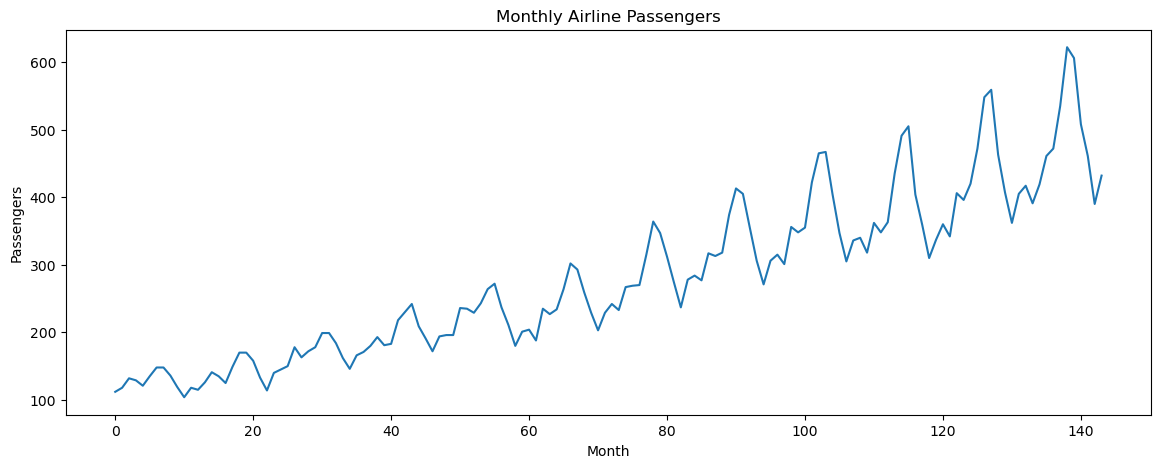

In [17]:
plt.figure(figsize=(14,5))

plt.plot(df["Passengers"])

plt.title("Monthly Airline Passengers")
plt.xlabel("Month")
plt.ylabel("Passengers")

plt.show()

## 🔧 Data Preprocessing

We will:

- Convert Month column into DateTime
- Set it as Index
- Prepare the data for forecasting

In [18]:
df["Month"] = pd.to_datetime(df["Month"])

df.set_index("Month", inplace=True)

df = df.asfreq("MS")

## ✂ Train-Test Split

We divide the dataset into:

- Training Data (80%)
- Testing Data (20%)

In [19]:
train_size = int(len(df)*0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

## 🤖 Model Building

Now we create the ARIMA model.

Model Used:

ARIMA(5,1,0)

In [20]:
model = ARIMA(train, order=(5,1,0))

model_fit = model.fit()

## 📈 Forecasting

Predict future passenger values using the testing dataset.

In [21]:
forecast = model_fit.forecast(steps=len(test))

## 📊 Model Evaluation

We will evaluate the forecasting model using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)

In [22]:
mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(mean_squared_error(test, forecast))

mape = np.mean(np.abs((test["Passengers"]-forecast)/test["Passengers"]))*100

print("MAE :",mae)
print("RMSE :",rmse)
print("MAPE :",mape)

MAE : 67.383500589532
RMSE : 80.66394528514422
MAPE : 16.15470562312459


## 📉 Forecast Visualization

Compare Actual and Forecasted Passenger Counts.

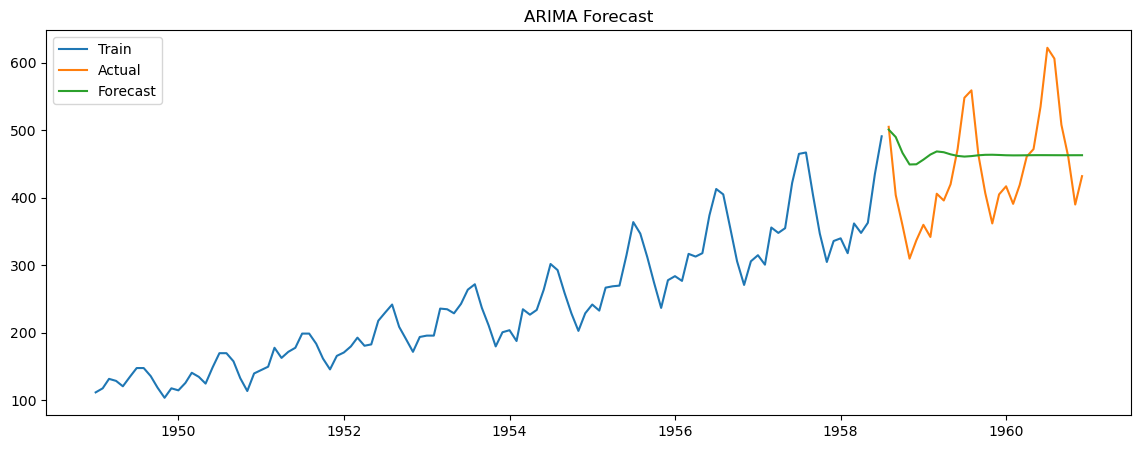

In [23]:
plt.figure(figsize=(14,5))

plt.plot(train.index, train["Passengers"], label="Train")

plt.plot(test.index, test["Passengers"], label="Actual")

plt.plot(test.index, forecast, label="Forecast")

plt.legend()

plt.title("ARIMA Forecast")

plt.show()

In [24]:
result = pd.DataFrame({
    "Actual": test["Passengers"],
    "Forecast": forecast
})

result.head(10)

,Actual,Forecast
1958-08-01,505,500.902643
1958-09-01,404,489.904481
1958-10-01,359,466.349010
1958-11-01,310,449.296639
1958-12-01,337,449.565682
1959-01-01,360,456.411345
1959-02-01,342,463.997445
1959-03-01,406,468.568886
1959-04-01,396,467.408711
1959-05-01,420,464.273767


<div style="
    background: linear-gradient(135deg, #effaf3, #edf4ff);
    border-left: 7px solid #2e9d62;
    padding: 24px;
    border-radius: 12px;
">

## ✅ Conclusion

In this notebook, we successfully implemented the ARIMA algorithm for time series forecasting.

The following steps were completed:

- Dataset Loading
- Data Exploration
- Time Series Visualization
- Data Preprocessing
- Train-Test Split
- ARIMA Model Building
- Forecast Generation
- Model Evaluation
- Forecast Visualization

ARIMA is one of the most popular statistical models for forecasting univariate time series data such as airline passengers, stock prices, weather observations, and monthly sales.